# Waze para La Estrella utilizando inteligencia artificial

## Fase 1: obtención y visualización del mapa

El objetivo del proyecto es desarrollar un método propio de búsqueda de rutas basado en A* para encontrar una ruta entre dos puntos de La Estrella, Antioquia. La función objetivo buscará minimizar el tiempo estimado de viaje en automóvil.

En esta primera fase se utilizará OSMnx para obtener la red vial de La Estrella como un grafo y mostrarla en un mapa.

### Importación de las bibliotecas

Se importan las bibliotecas empleadas en el ejemplo trabajado en clase. OSMnx permite obtener el mapa como un grafo con información geográfica de sus nodos y conexiones.

In [53]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, LineString

import matplotlib.pyplot as plt
import plotly.express as px

import networkx as nx
import osmnx as ox
import heapq
import math
import time

## Mapa de La Estrella

La función `graph_from_place` recibe el nombre del lugar que se desea consultar. El parámetro `network_type='drive'` indica que se quieren obtener las vías disponibles para recorridos en automóvil.

El parámetro `simplify=False` permite conservar más puntos de la red vial, como se realizó en el ejemplo de clase. Esto ofrece una representación más detallada del recorrido de las calles.

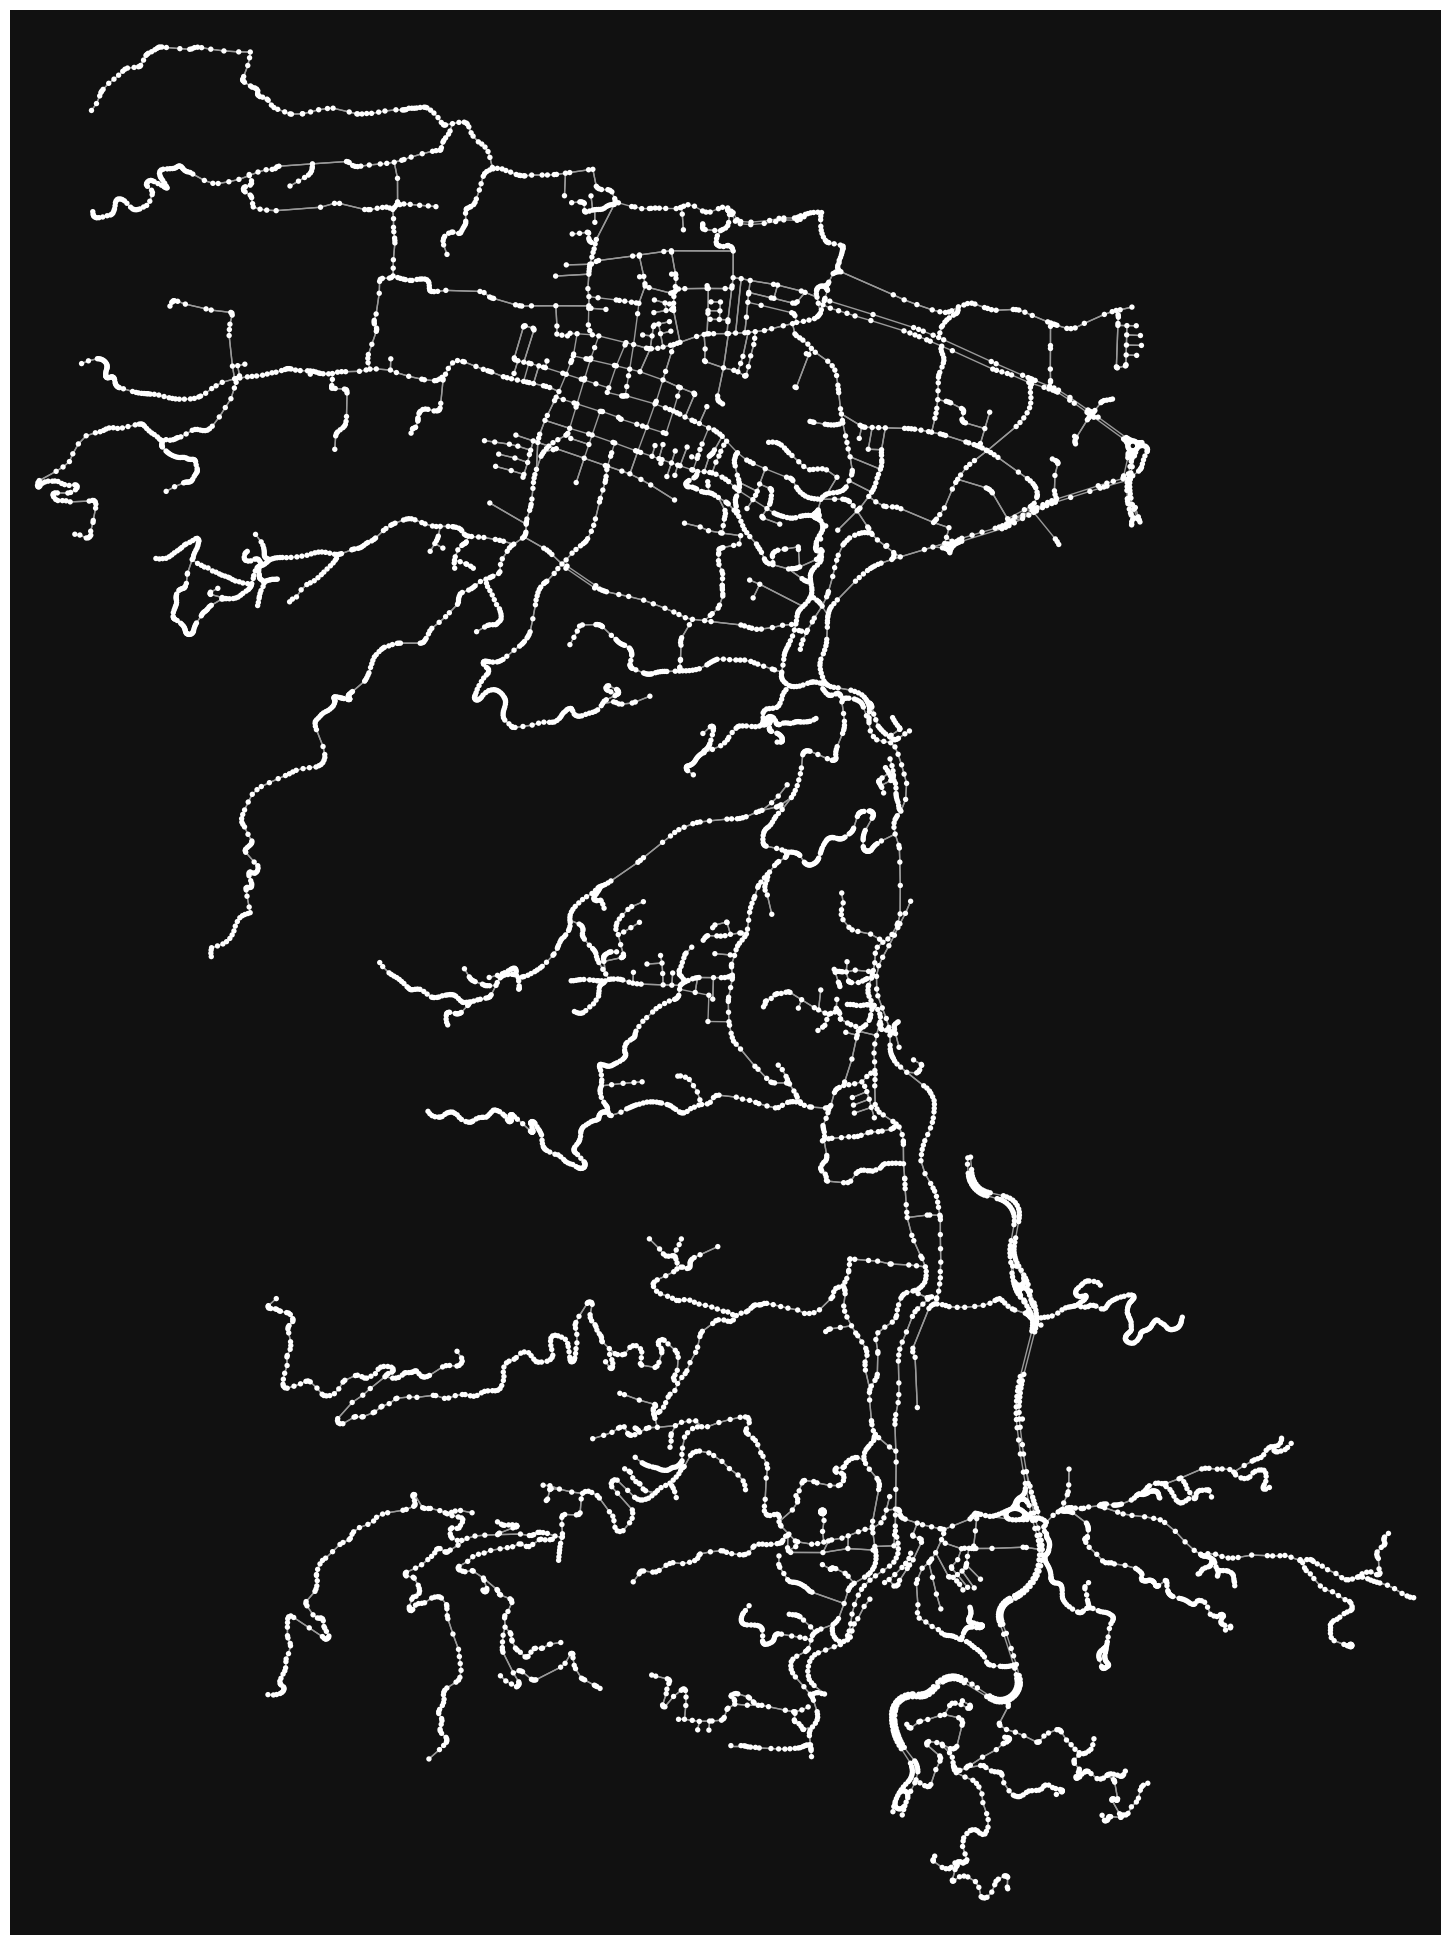

(<Figure size 2500x2500 with 1 Axes>, <Axes: >)

In [54]:
G = ox.graph_from_place('La Estrella, Antioquia, Colombia', network_type='drive', simplify=False)
ox.plot_graph(G, figsize=(25, 25))

### Información básica del mapa

El mapa se almacena en la variable `G`. Los nodos representan puntos de la red vial y las aristas representan las conexiones o tramos de calle entre esos puntos. Como se utilizó una red de tipo `drive`, se conservan los sentidos de circulación de las vías.

In [55]:
print('Cantidad de nodos:', len(G.nodes))
print('Cantidad de aristas:', len(G.edges))
print('Tipo de grafo:', type(G))

Cantidad de nodos: 7312
Cantidad de aristas: 13808
Tipo de grafo: <class 'networkx.classes.multidigraph.MultiDiGraph'>


## Resultado de la fase 1

Al finalizar esta fase se tiene en `G` el grafo de la red vial para automóviles de La Estrella y su representación gráfica. Este grafo será la base para seleccionar el origen y el destino y, posteriormente, implementar el algoritmo de búsqueda de rutas.

# Fase 2: definición del origen y el destino

En esta fase se localizarán los dos lugares de la demostración:

- **Origen:** unidad residencial Pitriza.
- **Destino:** corregimiento La Tablaza, La Estrella.

Primero se obtendrán sus coordenadas geográficas y se comprobarán las direcciones encontradas. Después, cada ubicación se asociará con el nodo más cercano de la red vial `G`.

## Búsqueda de latitud y longitud

Como se trabajó en clase, se utilizará la biblioteca `geopy` con el servicio gratuito Nominatim para buscar la latitud y longitud de lugares específicos. El parámetro `user_agent` identifica la aplicación que realiza la consulta.

In [56]:
import geopy
from geopy.geocoders import Nominatim

locator = Nominatim(user_agent='waze_ia_la_estrella')

Se consultan Pitriza y el corregimiento La Tablaza. Nominatim puede no reconocer un nombre o devolver un lugar diferente, por lo que también se guardan coordenadas verificadas como respaldo.

In [57]:
coordenadas_respaldo = {
    'Pitriza': (6.1562385, -75.6362846),
    'La Tablaza': (6.1181940, -75.6351392),
}

location_start = locator.geocode('Pitriza, La Estrella, Antioquia, Colombia')
location_end = locator.geocode('La Tablaza, La Estrella, Antioquia, Colombia')

## Verificación de las ubicaciones

Se muestran la dirección completa y las coordenadas encontradas. La Tablaza debe aparecer como un poblado o corregimiento de La Estrella. Si Nominatim no encuentra alguno de los lugares, se utilizarán las coordenadas de respaldo.

In [58]:
print('Origen encontrado:' if location_start else 'Origen: usando respaldo manual')
if location_start:
    print(location_start.address)
    print((location_start.latitude, location_start.longitude))
else:
    print(coordenadas_respaldo['Pitriza'])

print('\nDestino encontrado:' if location_end else '\nDestino: usando respaldo manual')
if location_end:
    print(location_end.address)
    print((location_end.latitude, location_end.longitude))
else:
    print(coordenadas_respaldo['La Tablaza'])

Origen encontrado:
Parque Pitriza, La Estrella, Valle de Aburrá, Antioquia, RAP del Agua y la Montaña, Colombia
(6.1562385, -75.6362846)

Destino encontrado:
La Tablaza, La Estrella, Valle de Aburrá, Antioquia, RAP del Agua y la Montaña, 055450, Colombia
(6.118194, -75.6351392)


Las coordenadas se guardan como tuplas en el orden `(latitud, longitud)`. Cuando la geocodificación está disponible se usa su resultado; en caso contrario se emplea el respaldo manual verificado.

In [59]:
start = (location_start.latitude, location_start.longitude) if location_start else coordenadas_respaldo['Pitriza']
end = (location_end.latitude, location_end.longitude) if location_end else coordenadas_respaldo['La Tablaza']

print('Coordenadas del origen:', start)
print('Coordenadas del destino:', end)

Coordenadas del origen: (6.1562385, -75.6362846)
Coordenadas del destino: (6.118194, -75.6351392)


## Asociación con la red vial

El algoritmo A* trabajará con identificadores de nodos y no directamente con coordenadas. La función `nearest_nodes` busca el nodo de `G` más cercano a cada lugar. OSMnx recibe primero la longitud (`X`) y después la latitud (`Y`), por eso se utilizan `start[1], start[0]` y `end[1], end[0]`.

In [60]:
start_node = ox.distance.nearest_nodes(G, start[1], start[0])
end_node = ox.distance.nearest_nodes(G, end[1], end[0])

print('Nodo vial del origen:', start_node)
print('Nodo vial del destino:', end_node)

Nodo vial del origen: 8449802805
Nodo vial del destino: 5404450848


## Visualización del origen y el destino

Se dibujan las coordenadas encontradas y sus nodos viales más cercanos: Pitriza en rojo y La Tablaza en verde. Los cuadrados representan los lugares originales y los círculos, los nodos que utilizará A*.

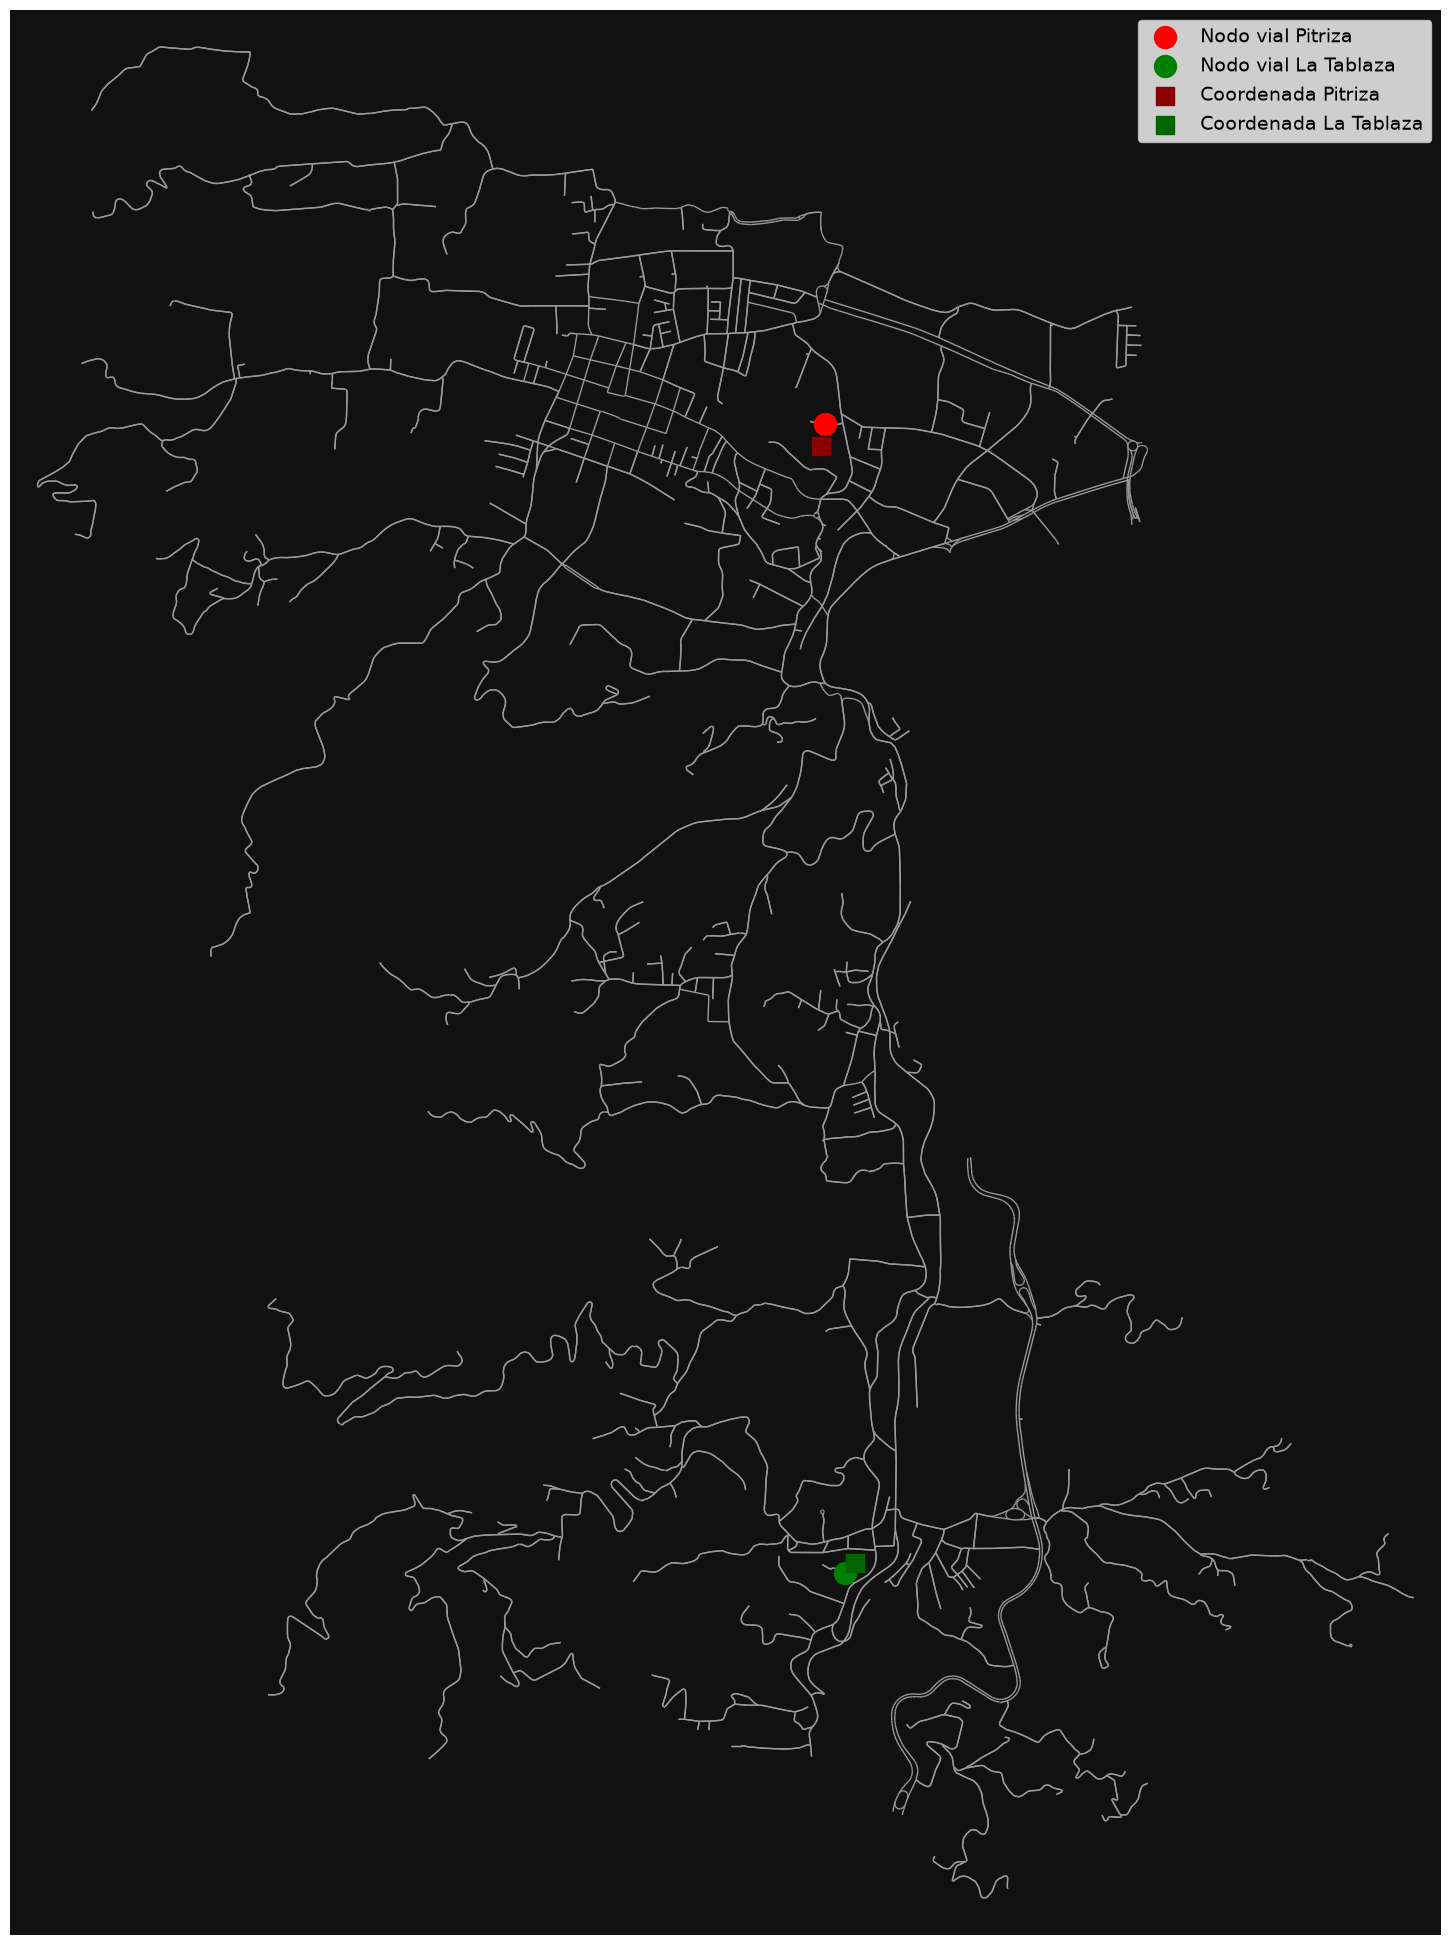

In [61]:
fig, ax = ox.plot_graph(G, figsize=(25, 25), node_size=0, show=False, close=False)

ax.scatter(G.nodes[start_node]['x'], G.nodes[start_node]['y'],
           c='red', s=250, label='Nodo vial Pitriza', zorder=3)
ax.scatter(G.nodes[end_node]['x'], G.nodes[end_node]['y'],
           c='green', s=250, label='Nodo vial La Tablaza', zorder=3)
ax.scatter(start[1], start[0], c='darkred', s=180, marker='s',
           label='Coordenada Pitriza', zorder=4)
ax.scatter(end[1], end[0], c='darkgreen', s=180, marker='s',
           label='Coordenada La Tablaza', zorder=4)

ax.legend(fontsize=14)
plt.show()

## Resultado de la fase 2

Al finalizar esta fase quedan definidas las coordenadas `start` y `end`, junto con los nodos viales `start_node` y `end_node`. Estos identificadores serán el estado inicial y el estado objetivo de la búsqueda de rutas.

# Fase 3: preparación y revisión de los datos viales

En esta fase se preparan los datos que permitirán medir el costo de recorrer cada tramo de la red vial. El costo base será el tiempo estimado de viaje (`travel_time`), calculado a partir de la longitud de la calle y su velocidad estimada.

También se revisará cuánta información ofrece OpenStreetMap sobre las variables seleccionadas para el proyecto: distancia, velocidad, tiempo, tipo de vía, giros e intersecciones.

## Velocidades estimadas por tipo de vía

Algunas calles tienen el atributo `maxspeed`, pero otras no. Como se enseñó en clase, se crea un diccionario `hwy_speeds` con velocidades predeterminadas en kilómetros por hora. OSMnx utiliza estos valores para completar `speed_kph` cuando falta una velocidad.

Los valores son supuestos iniciales del modelo y se podrán ajustar posteriormente. No representan información de tráfico en tiempo real.

In [62]:
hwy_speeds = {
    'motorway': 80,
    'trunk': 60,
    'primary': 50,
    'secondary': 40,
    'tertiary': 35,
    'residential': 30,
    'unclassified': 30,
    'service': 20
}

hwy_speeds

{'motorway': 80,
 'trunk': 60,
 'primary': 50,
 'secondary': 40,
 'tertiary': 35,
 'residential': 30,
 'unclassified': 30,
 'service': 20}

## Cálculo de velocidad y tiempo de viaje

La función `add_edge_speeds` crea el atributo `speed_kph`. Después, `add_edge_travel_times` calcula el tiempo necesario para recorrer cada arista y lo guarda en `travel_time`, expresado en segundos.

No se sumarán distancia, velocidad y tiempo como costos independientes: el tiempo ya se calcula utilizando la distancia y la velocidad.

In [63]:
G = ox.add_edge_speeds(G, hwy_speeds=hwy_speeds)
G = ox.add_edge_travel_times(G)
G = ox.add_edge_bearings(G)

print('Velocidades, tiempos de viaje y orientaciones calculados correctamente.')

Velocidades, tiempos de viaje y orientaciones calculados correctamente.


## Información de nodos y aristas

Como en el ejemplo de clase, `graph_to_gdfs` convierte el grafo en dos tablas geográficas: `gdf_nodes` para los nodos y `gdf_edges` para las calles.

In [64]:
gdf_nodes, gdf_edges = ox.graph_to_gdfs(G)
gdf_edges.head()

osmid     highway lanes maxspeed  \
u         v           key                                          
322010859 11933215278 0     440843501       trunk     3       80   
322010907 9369408441  0     384110369       trunk     2       80   
          9392365640  0    1018297125  trunk_link     1      NaN   
322010909 11933215257 0     384110369       trunk     2       80   
322010911 4121909108  0     384110369       trunk     2       80   

                                         name  oneway  ref  reversed  \
u         v           key                                              
322010859 11933215278 0    Avenida Carrera 42    True   25     False   
322010907 9369408441  0    Avenida Carrera 42    True   25     False   
          9392365640  0                   NaN    True  NaN     False   
322010909 11933215257 0    Avenida Carrera 42    True   25     False   
322010911 4121909108  0    Avenida Carrera 42    True   25     False   

                              length  speed_kph  travel_time     bearing  \
u         v           key                                                  
322010859 11933215278 0    19.641968  80.000000     0.883889  244.983211   
322010907 9369408441  0    35.111248  80.000000     1.580006  242.070184   
          9392365640  0    37.208254  40.318182     3.322315  257.995064   
322010909 11933215257 0    20.267521  80.000000     0.912038  247.279246   
322010911 4121909108  0    60.862245  80.000000     2.738801  252.520912   

                          bridge width junction access  \
u         v           key                                
322010859 11933215278 0      NaN   NaN      NaN    NaN   
322010907 9369408441  0      NaN   NaN      NaN    NaN   
          9392365640  0      NaN   NaN      NaN    NaN   
322010909 11933215257 0      NaN   NaN      NaN    NaN   
322010911 4121909108  0      NaN   NaN      NaN    NaN   

                                                                    geometry  
u         v           key                                                     
322010859 11933215278 0    LINESTRING (-75.62853 6.15432, -75.62869 6.15424)  
322010907 9369408441  0    LINESTRING (-75.62939 6.15377, -75.62967 6.15363)  
          9392365640  0     LINESTRING (-75.62939 6.15377, -75.62972 6.1537)  
322010909 11933215257 0    LINESTRING (-75.62839 6.15428, -75.62856 6.15421)  
322010911 4121909108  0    LINESTRING (-75.62774 6.15449, -75.62826 6.15433)

La siguiente tabla resume la longitud, velocidad y tiempo promedio según el tipo de vía. Sigue el mismo análisis realizado en el cuaderno trabajado en clase.

In [65]:
gdf_edges.explode('highway').groupby('highway')[['length', 'speed_kph', 'travel_time']].mean().round(1)

,length,speed_kph,travel_time
highway,,,
residential,16.9,30.0,2.0
secondary,22.4,39.7,2.1
secondary_link,7.2,30.0,0.9
tertiary,20.5,33.4,2.3
tertiary_link,6.1,28.2,0.8
trunk,18.8,40.5,1.8
trunk_link,11.2,40.3,1.0
unclassified,18.7,30.0,2.2


## Revisión de la cobertura de los atributos

Antes de utilizar un atributo en el modelo se debe comprobar si está presente en suficientes calles. La tabla muestra cuántas aristas tienen cada variable y qué porcentaje representan dentro de la red.

In [66]:
atributos_viales = ['length', 'speed_kph', 'travel_time', 'highway', 'bearing']
cantidad_aristas = len(gdf_edges)
cobertura = []

for atributo in atributos_viales:
    if atributo in gdf_edges.columns:
        datos_disponibles = int(gdf_edges[atributo].notna().sum())
    else:
        datos_disponibles = 0

    cobertura.append({
        'atributo': atributo,
        'datos disponibles': datos_disponibles,
        'datos faltantes': cantidad_aristas - datos_disponibles,
        'cobertura (%)': round(datos_disponibles / cantidad_aristas * 100, 2)
    })

tabla_cobertura = pd.DataFrame(cobertura)
tabla_cobertura

,atributo,datos disponibles,datos faltantes,cobertura (%)
0,length,13808,0,100.0
1,speed_kph,13808,0,100.0
2,travel_time,13808,0,100.0
3,highway,13808,0,100.0
4,bearing,13808,0,100.0


## Tipos de vía encontrados

OpenStreetMap puede guardar `highway` como un texto o como una lista cuando un tramo reúne varias clasificaciones. Por eso se normalizan los valores antes de contarlos.

In [67]:
def normalizar_valor_osm(valor):
    if isinstance(valor, list):
        return ', '.join(map(str, valor))
    return valor

tipos_via = gdf_edges['highway'].apply(normalizar_valor_osm).value_counts(dropna=False)
tipos_via.to_frame(name='cantidad de aristas')

,cantidad de aristas
highway,
residential,10014
unclassified,1474
tertiary,1266
secondary,495
trunk,420
trunk_link,122
tertiary_link,13
secondary_link,4


## Información necesaria para calcular giros

OSMnx calcula `bearing`, la orientación de cada arista en grados. Un giro no es un atributo aislado de una calle: se obtiene comparando la orientación de la arista por la que se llega con la orientación de la arista por la que se sale.

La diferencia angular se interpreta inicialmente así: menos de 30° es continuar aproximadamente recto, entre 30° y 150° es un giro, y más de 150° es un retorno. Para evitar confundir los puntos de una curva con intersecciones, se analizan nodos conectados con tres o más calles.

In [68]:
def diferencia_angular(bearing_entrada, bearing_salida):
    return abs((bearing_salida - bearing_entrada + 180) % 360 - 180)

def clasificar_movimiento(angulo):
    if angulo < 30:
        return 'recto'
    if angulo <= 150:
        return 'giro'
    return 'retorno'

movimientos = []
for nodo in G.nodes:
    if G.nodes[nodo].get('street_count', 0) < 3:
        continue

    for u, _, key_in, datos_in in G.in_edges(nodo, keys=True, data=True):
        for _, v, key_out, datos_out in G.out_edges(nodo, keys=True, data=True):
            if 'bearing' not in datos_in or 'bearing' not in datos_out:
                continue

            angulo = diferencia_angular(datos_in['bearing'], datos_out['bearing'])
            movimientos.append({
                'nodo': nodo,
                'arista_entrada': (u, nodo, key_in),
                'arista_salida': (nodo, v, key_out),
                'diferencia_angular': round(angulo, 1),
                'movimiento': clasificar_movimiento(angulo)
            })

df_movimientos = pd.DataFrame(movimientos)
print('Movimientos posibles analizados:', len(df_movimientos))
df_movimientos['movimiento'].value_counts().to_frame(name='cantidad')

Movimientos posibles analizados: 3989


,cantidad
movimiento,
giro,1707
retorno,1255
recto,1027


## Intersecciones de la red vial

OSMnx almacena `street_count` en cada nodo para indicar cuántas calles físicas están conectadas. Se considerará una intersección relevante cuando `street_count >= 3`: los nodos con una sola calle suelen ser extremos y los nodos con dos conexiones normalmente representan continuidad de una vía.

La cantidad de calles permitirá modelar posteriormente una demora configurable: una intersección con cuatro o más conexiones puede considerarse más compleja que una con tres.

In [69]:
nodos_interseccion = [
    nodo for nodo, datos in G.nodes(data=True)
    if datos.get('street_count', 0) >= 3
]

df_intersecciones = pd.DataFrame([
    {
        'nodo': nodo,
        'cantidad_calles': G.nodes[nodo]['street_count'],
        'longitud': G.nodes[nodo]['x'],
        'latitud': G.nodes[nodo]['y']
    }
    for nodo in nodos_interseccion
])

print('Cantidad de intersecciones:', len(nodos_interseccion))
df_intersecciones['cantidad_calles'].value_counts().sort_index().to_frame(
    name='cantidad de intersecciones'
)

Cantidad de intersecciones: 535


,cantidad de intersecciones
cantidad_calles,
3,482
4,50
5,3


## Reglas para los datos faltantes

Para mantener un modelo reproducible se utilizarán estas reglas iniciales:

- **Longitud:** OSMnx calcula `length` para todas las aristas al construir el grafo.
- **Velocidad:** si falta `maxspeed`, se estima `speed_kph` con el diccionario `hwy_speeds`; OSMnx completa otros casos con valores representativos de la red.
- **Tiempo:** se calcula en segundos a partir de `length` y `speed_kph`.
- **Tipo de vía:** se conserva el atributo `highway` de OpenStreetMap.
- **Giros:** se calculan comparando el `bearing` de dos aristas consecutivas en una intersección; no dependen de una etiqueta de OpenStreetMap.
- **Intersecciones:** se identifican con `street_count >= 3` y su complejidad inicial se representa mediante la cantidad de calles conectadas.
- **Pendiente:** no se calcula todavía porque requiere incorporar elevaciones desde otra fuente.

## Resultado de la fase 3

Al finalizar esta fase, cada arista del grafo `G` tiene una velocidad estimada (`speed_kph`), un tiempo de viaje (`travel_time`) y una orientación (`bearing`). Además, `df_movimientos` contiene los posibles giros y `df_intersecciones` resume las intersecciones y su cantidad de calles conectadas.

# Fase 4: creación de la clase `OSMRouteMap`

La clase `OSMRouteMap` adapta la idea de `RouteMap` del cuaderno trabajado en clase a una red vial de OpenStreetMap. En este caso, cada estado es el identificador de un nodo de `G` y los operadores son las aristas dirigidas que salen de él.

A diferencia del mapa pequeño del ejemplo, `G` es un `MultiDiGraph`: puede haber varias aristas entre los mismos dos nodos. Por eso cada vecino conserva también la clave (`key`) de la arista que lo conecta.

## Costos y heurística

### Costo de las aristas

La función `edge_travel_cost` utiliza actualmente el atributo `travel_time` proporcionado por OSMnx como costo de cada arista. Por lo tanto, todos los costos se expresan en **segundos** y representan el tiempo estimado necesario para recorrer cada tramo de la red vial.

En esta fase no se aplican penalizaciones adicionales. La clase conserva una configuración (`config`) que permitirá incorporar posteriormente el factor por tipo de vía (`highway`) y la demora por complejidad de intersección (`street_count`) sin modificar la interfaz principal de `OSMRouteMap`.

### Heurística

La función heurística estima el tiempo mínimo restante entre un nodo y el destino. Para ello, primero calcula la distancia geográfica en línea recta entre ambos nodos mediante la **fórmula de Haversine** y posteriormente convierte esa distancia en un tiempo utilizando la mayor velocidad disponible en el grafo:


$h(n) = \frac{d(n, destino)}{v_{\\max}}$


donde:

- d(n, destino) es la distancia en línea recta entre el nodo actual y el destino.
- v_max es la mayor velocidad registrada en la red vial.
- h(n) es el tiempo estimado restante, expresado en segundos.

Esta elección busca que la heurística sea **admisible** para A*. La distancia en línea recta es una cota inferior de cualquier distancia que deba recorrerse utilizando la red vial, mientras que utilizar la velocidad máxima produce el menor tiempo posible para recorrer dicha distancia. Por esta razón, la estimación no sobreestima el costo real de alcanzar el destino:


$h(n) \leq h^*(n)$


donde $h^*(n)$ representa el costo real mínimo desde el nodo $n$ hasta el destino.

La heurística, por tanto, proporciona una estimación optimista del tiempo restante sin incorporar las penalizaciones del costo real. Si se configura manualmente `max_speed_kph`, su valor debe ser igual o superior a la mayor velocidad del grafo para conservar esta propiedad.


In [70]:
class OSMRouteMap:
    """
    Consultas, costos y heurística para una red vial dirigida
    obtenida de OpenStreetMap mediante OSMnx.

    La función objetivo es minimizar el tiempo estimado de viaje
    en automóvil.
    """

    def __init__(self, graph, config=None):
        self.graph = graph
        self.config = dict(config) if config is not None else {}

        # La velocidad de referencia nunca puede ser menor que la
        # velocidad máxima real del grafo, porque la heurística
        # podría dejar de ser admisible.
        graph_max_speed_kph = self._maximum_speed_kph()

        if 'max_speed_kph' in self.config:
            self.max_speed_kph = float(self.config['max_speed_kph'])
        else:
            self.max_speed_kph = graph_max_speed_kph

        if (
            not math.isfinite(self.max_speed_kph)
            or self.max_speed_kph <= 0
        ):
            raise ValueError(
                'max_speed_kph debe ser un número positivo.'
            )

        if self.max_speed_kph < graph_max_speed_kph:
            raise ValueError(
                'max_speed_kph debe ser igual o superior a la '
                'velocidad máxima del grafo '
                f'({graph_max_speed_kph:.1f} km/h).'
            )

    @staticmethod
    def _as_numbers(value):
        """
        Convierte valores simples o listas de OSM en números válidos.

        OSM puede almacenar algunos atributos como:
            30
            '30'
            ['30', '40']
        """
        values = (
            value
            if isinstance(value, (list, tuple))
            else [value]
        )

        numbers = []

        for item in values:
            try:
                number = float(item)
            except (TypeError, ValueError):
                continue

            if math.isfinite(number):
                numbers.append(number)

        return numbers

    def _maximum_speed_kph(self):
        """
        Obtiene la mayor velocidad válida presente en las aristas.

        Esta velocidad se utiliza como referencia para construir
        la heurística temporal.
        """
        speeds = []

        for _, _, edge_data in self.graph.edges(data=True):
            speeds.extend(
                self._as_numbers(
                    edge_data.get('speed_kph')
                )
            )

        if not speeds:
            raise ValueError(
                'El grafo no contiene valores válidos de speed_kph.'
            )

        return max(speeds)

    def neighbors(self, node_id):
        """
        Devuelve las aristas salientes de node_id.

        Cada elemento tiene la forma:

            (neighbor_id, key, edge_data)

        Se utilizan out_edges() y keys=True para:
        - respetar el sentido de circulación;
        - conservar las aristas paralelas.
        """
        return [
            (neighbor_id, key, edge_data)
            for _, neighbor_id, key, edge_data
            in self.graph.out_edges(
                node_id,
                keys=True,
                data=True
            )
        ]

    def edge_travel_cost(
        self,
        u,
        v,
        key,
        edge_data
    ):
        """
        Devuelve el costo de recorrer una arista en segundos.

        El costo corresponde directamente a travel_time,
        calculado previamente por OSMnx.
        """
        travel_times = self._as_numbers(
            edge_data.get('travel_time')
        )

        if not travel_times:
            raise ValueError(
                f'La arista ({u}, {v}, {key}) '
                'no tiene un travel_time válido.'
            )

        travel_time = travel_times[0]

        if travel_time < 0:
            raise ValueError(
                f'La arista ({u}, {v}, {key}) '
                'tiene un costo negativo.'
            )

        return travel_time

    def heuristic(self, node_id, destination_id):
        """
        Estima en segundos el tiempo mínimo restante desde
        node_id hasta destination_id.

        La estimación se obtiene mediante:

            distancia en línea recta / velocidad máxima

        La distancia se calcula mediante la fórmula de Haversine.

        Utilizar la distancia en línea recta proporciona una
        distancia mínima posible entre ambos nodos. Utilizar la
        velocidad máxima proporciona el menor tiempo físicamente
        posible bajo el modelo utilizado.

        Por tanto, la heurística no sobreestima el tiempo real
        de viaje y es admisible para A* bajo este modelo.
        """
        if node_id == destination_id:
            return 0.0

        origin = self.graph.nodes[node_id]
        destination = self.graph.nodes[destination_id]

        # Coordenadas geográficas de los nodos.
        lat1 = math.radians(origin['y'])
        lon1 = math.radians(origin['x'])

        lat2 = math.radians(destination['y'])
        lon2 = math.radians(destination['x'])

        # Diferencias angulares.
        delta_lat = lat2 - lat1
        delta_lon = lon2 - lon1

        # Fórmula de Haversine.
        a = (
            math.sin(delta_lat / 2) ** 2
            + math.cos(lat1)
            * math.cos(lat2)
            * math.sin(delta_lon / 2) ** 2
        )

        # Evita pequeños errores numéricos fuera del intervalo [0, 1].
        a = min(1.0, max(0.0, a))

        earth_radius_m = 6_371_008.8

        distance_m = (
            2
            * earth_radius_m
            * math.asin(math.sqrt(a))
        )

        # Conversión:
        #
        # distancia_m / (km/h)
        # ->
        # segundos
        #
        # 1 km/h = 1/3.6 m/s
        estimated_time_s = (
            distance_m * 3.6 / self.max_speed_kph
        )

        return estimated_time_s

    def a_star(self, start_id, destination_id):
        """
        Encuentra una ruta de costo temporal mínimo mediante A*.

        La frontera utiliza heapq y ordena los estados por:

            f(n) = g(n) + h(n)

        El resultado contiene la ruta, su costo y métricas de la
        búsqueda. Si no existe una ruta, found es False.
        """
        if start_id not in self.graph:
            raise ValueError(
                f'El nodo de origen {start_id} no existe en el grafo.'
            )

        if destination_id not in self.graph:
            raise ValueError(
                f'El nodo de destino {destination_id} no existe en el grafo.'
            )

        started_at = time.perf_counter()

        # Cada entrada contiene:
        # (f_score, g_al_insertar, contador, node_id)
        # El contador evita comparar identificadores en caso de empate.
        frontier = []
        push_counter = 0

        g_score = {start_id: 0.0}
        came_from = {}
        explored_nodes = set()

        initial_f = self.heuristic(start_id, destination_id)
        heapq.heappush(
            frontier,
            (initial_f, 0.0, push_counter, start_id)
        )

        while frontier:
            _, queued_g, _, current = heapq.heappop(frontier)

            # Una mejora posterior puede dejar entradas antiguas
            # dentro del heap. Esas entradas se descartan aquí.
            if queued_g > g_score.get(current, math.inf):
                continue

            explored_nodes.add(current)

            if current == destination_id:
                route_nodes, route_edges = self.reconstruct_route(
                    came_from,
                    destination_id
                )

                return {
                    'found': True,
                    'route_nodes': route_nodes,
                    'route_edges': route_edges,
                    'total_cost_s': g_score[destination_id],
                    'explored_nodes': len(explored_nodes),
                    'elapsed_time_s': time.perf_counter() - started_at,
                    'message': 'Ruta encontrada.'
                }

            for neighbor, key, edge_data in self.neighbors(current):
                step_cost = self.edge_travel_cost(
                    current,
                    neighbor,
                    key,
                    edge_data
                )
                tentative_g = queued_g + step_cost

                if tentative_g < g_score.get(neighbor, math.inf):
                    g_score[neighbor] = tentative_g
                    came_from[neighbor] = (current, key)

                    push_counter += 1
                    estimated_f = (
                        tentative_g
                        + self.heuristic(neighbor, destination_id)
                    )
                    heapq.heappush(
                        frontier,
                        (
                            estimated_f,
                            tentative_g,
                            push_counter,
                            neighbor
                        )
                    )

        return {
            'found': False,
            'route_nodes': [],
            'route_edges': [],
            'total_cost_s': math.inf,
            'explored_nodes': len(explored_nodes),
            'elapsed_time_s': time.perf_counter() - started_at,
            'message': (
                f'No existe una ruta dirigida entre {start_id} '
                f'y {destination_id}.'
            )
        }

    def reconstruct_route(
        self,
        came_from,
        destination_id
    ):
        """
        Reconstruye los nodos y las aristas desde el destino.

        came_from guarda para cada nodo:

            node_id -> (predecessor_id, edge_key)
        """
        route_nodes = [destination_id]
        route_edges = []
        current = destination_id

        while current in came_from:
            predecessor, key = came_from[current]
            route_edges.append((predecessor, current, key))
            current = predecessor
            route_nodes.append(current)

        route_nodes.reverse()
        route_edges.reverse()

        return route_nodes, route_edges

## Resultado de la fase 4

`OSMRouteMap` permite consultar únicamente las aristas alcanzables, distinguir aristas paralelas, obtener el costo temporal de cada tramo y estimar el tiempo restante hasta un destino.

# Fase 5: implementación de A* desde cero

El método `a_star` utiliza una cola de prioridad construida con `heapq`. Para cada nodo mantiene el menor tiempo conocido en `g_score` y su predecesor junto con la clave de la arista en `came_from`.

La prioridad de cada entrada es `f(n) = g(n) + h(n)`. Cuando se encuentra una ruta más rápida hacia un nodo, se inserta una entrada nueva; las entradas antiguas se reconocen por su valor de `g` y se descartan al extraerlas. De esta forma no es necesario modificar elementos dentro del heap.

La búsqueda termina cuando el destino es extraído con su mejor costo conocido. `reconstruct_route` recorre `came_from` hacia atrás y devuelve tanto la secuencia de nodos como las aristas `(u, v, key)` seleccionadas. No se utiliza ningún algoritmo de rutas de NetworkX.

In [71]:
route_map = OSMRouteMap(G)
resultado_astar = route_map.a_star(start_node, end_node)

print(resultado_astar['message'])
print('Nodo de origen:', start_node)
print('Nodo de destino:', end_node)

if resultado_astar['found']:
    print('Inicio de la ruta:', resultado_astar['route_nodes'][0])
    print('Final de la ruta:', resultado_astar['route_nodes'][-1])
    print('Cantidad de nodos de la ruta:', len(resultado_astar['route_nodes']))
    print('Cantidad de aristas de la ruta:', len(resultado_astar['route_edges']))
    print('Costo temporal (s):', round(resultado_astar['total_cost_s'], 2))
    print('Costo temporal (min):', round(resultado_astar['total_cost_s'] / 60, 2))

print('Nodos explorados:', resultado_astar['explored_nodes'])
print('Duración de la búsqueda (s):', round(resultado_astar['elapsed_time_s'], 6))

Ruta encontrada.
Nodo de origen: 8449802805
Nodo de destino: 5404450848
Inicio de la ruta: 8449802805
Final de la ruta: 5404450848
Cantidad de nodos de la ruta: 230
Cantidad de aristas de la ruta: 229
Costo temporal (s): 507.24
Costo temporal (min): 8.45
Nodos explorados: 3235
Duración de la búsqueda (s): 0.027182


## Resultado de la fase 5

La clase ya puede encontrar una ruta dirigida entre Pitriza y La Tablaza mediante una implementación propia de A*. El resultado conserva los nodos y las claves de las aristas seleccionadas, el costo total en segundos, la cantidad de nodos explorados y la duración de la búsqueda. Si el destino no es alcanzable, el método devuelve `found=False`, rutas vacías y un mensaje explícito.

# Fase 6: validación de la versión mínima

La primera configuración utiliza únicamente la suma de `travel_time` como costo real `g(n)` y el tiempo en línea recta como heurística `h(n)`.

Primero se comprueba que la ruta comience y termine en los nodos esperados, que cada arista exista en el `MultiDiGraph` con el sentido y la clave indicados, que todos los costos sean finitos y no negativos, y que la suma de los tramos coincida con el costo reportado por A*. Las instrucciones `assert` hacen que la ejecución se detenga si alguna propiedad no se cumple.

In [72]:
route_nodes = resultado_astar['route_nodes']
route_edges = resultado_astar['route_edges']

empieza_en_origen = (
    resultado_astar['found']
    and route_nodes[0] == start_node
)
termina_en_destino = (
    resultado_astar['found']
    and route_nodes[-1] == end_node
)
cantidad_consistente = (
    len(route_nodes) == len(route_edges) + 1
)

aristas_dirigidas_validas = all(
    u == route_nodes[index]
    and v == route_nodes[index + 1]
    and G.has_edge(u, v, key)
    for index, (u, v, key) in enumerate(route_edges)
)

costos_tramos = [
    route_map.edge_travel_cost(
        u,
        v,
        key,
        G.edges[u, v, key]
    )
    for u, v, key in route_edges
]
costos_validos = all(
    math.isfinite(costo) and costo >= 0
    for costo in costos_tramos
)
costo_recalculado_s = sum(costos_tramos)
costo_coincide = math.isclose(
    costo_recalculado_s,
    resultado_astar['total_cost_s'],
    rel_tol=1e-12,
    abs_tol=1e-9
)
heuristica_destino_cero = math.isclose(
    route_map.heuristic(end_node, end_node),
    0.0,
    abs_tol=1e-12
)

validaciones_astar = pd.DataFrame({
    'validación': [
        'Ruta encontrada',
        'Empieza en el origen',
        'Termina en el destino',
        'Cantidad nodos/aristas consistente',
        'Aristas dirigidas y claves válidas',
        'Costos finitos y no negativos',
        'Suma de costos coincide',
        'h(destino) = 0',
    ],
    'cumple': [
        resultado_astar['found'],
        empieza_en_origen,
        termina_en_destino,
        cantidad_consistente,
        aristas_dirigidas_validas,
        costos_validos,
        costo_coincide,
        heuristica_destino_cero,
    ]
})

assert validaciones_astar['cumple'].all(), (
    'La ruta A* no superó todas las validaciones.'
)

print('Costo reportado (s):', resultado_astar['total_cost_s'])
print('Costo recalculado (s):', costo_recalculado_s)
validaciones_astar

Costo reportado (s): 507.2424427411608
Costo recalculado (s): 507.2424427411608


,validación,cumple
0,Ruta encontrada,True
1,Empieza en el origen,True
2,Termina en el destino,True
3,Cantidad nodos/aristas consistente,True
4,Aristas dirigidas y claves válidas,True
5,Costos finitos y no negativos,True
6,Suma de costos coincide,True
7,h(destino) = 0,True


## Comparación con costo uniforme propio

Para comprobar el costo encontrado se reutiliza exactamente el método `a_star`, pero se redefine `heuristic` para que siempre devuelva cero. En consecuencia, la prioridad se convierte en `f(n) = g(n)` y la búsqueda se comporta como costo uniforme. Esta validación tampoco utiliza algoritmos de rutas de NetworkX.

In [73]:
class UniformCostRouteMap(OSMRouteMap):
    def heuristic(self, node_id, destination_id):
        return 0.0


uniform_cost_map = UniformCostRouteMap(G)
resultado_costo_uniforme = uniform_cost_map.a_star(
    start_node,
    end_node
)

costos_iguales = (
    resultado_costo_uniforme['found']
    and math.isclose(
        resultado_astar['total_cost_s'],
        resultado_costo_uniforme['total_cost_s'],
        rel_tol=1e-12,
        abs_tol=1e-9
    )
)

assert resultado_costo_uniforme['found'], (
    'La búsqueda de costo uniforme no encontró una ruta.'
)
assert costos_iguales, (
    'A* y costo uniforme encontraron costos diferentes.'
)

comparacion_busquedas = pd.DataFrame([
    {
        'algoritmo': 'A*',
        'costo total (s)': resultado_astar['total_cost_s'],
        'nodos explorados': resultado_astar['explored_nodes'],
        'duración (s)': resultado_astar['elapsed_time_s'],
    },
    {
        'algoritmo': 'Costo uniforme propio',
        'costo total (s)': resultado_costo_uniforme['total_cost_s'],
        'nodos explorados': resultado_costo_uniforme['explored_nodes'],
        'duración (s)': resultado_costo_uniforme['elapsed_time_s'],
    },
])

comparacion_busquedas['costo total (s)'] = (
    comparacion_busquedas['costo total (s)'].round(6)
)
comparacion_busquedas['duración (s)'] = (
    comparacion_busquedas['duración (s)'].round(6)
)

print('Los costos encontrados son iguales:', costos_iguales)
comparacion_busquedas

Los costos encontrados son iguales: True


,algoritmo,costo total (s),nodos explorados,duración (s)
0,A*,507.242443,3235,0.027182
1,Costo uniforme propio,507.242443,4498,0.029017


## Resultado de la fase 6

La ruta supera las validaciones estructurales y numéricas. A* y la búsqueda de costo uniforme propia encuentran el mismo costo, lo que aporta evidencia de que la implementación mínima funciona correctamente. La comparación de nodos explorados permite observar el efecto de utilizar la heurística temporal.